In [10]:
# Step 1 — Load Required Data

import numpy as np

X_seq = np.load("X_seq.npy")
y_seq = np.load("y_seq.npy")

print("Data Loaded Successfully")
print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

Data Loaded Successfully
X shape: (912940, 30, 12)
y shape: (912940,)


In [11]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_val = X_seq[split:]

y_train = y_seq[:split]
y_val = y_seq[split:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (730352, 30, 12)
Validation shape: (182588, 30, 12)


In [12]:
X_train = X_train[:150000]
y_train = y_train[:150000]

In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, Dropout, GlobalAveragePooling1D

In [14]:
def transformer_model(input_shape):

    inputs = Input(shape=input_shape)

    # Self Attention
    attention = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)

    # Add & Normalize
    x = LayerNormalization(epsilon=1e-6)(inputs + attention)

    # Feed Forward
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.1)(x)

    # Pooling
    x = GlobalAveragePooling1D()(x)

    # Output Layer
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    return model

In [15]:
model_tf = transformer_model((X_train.shape[1], X_train.shape[2]))

model_tf.compile(
    optimizer='adam',
    loss='mse'
)

model_tf.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 30, 12)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 30, 12)            │           6,540 │ input_layer[0][0],         │
│ (MultiHeadAttention)          │                           │                 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 30, 12)            │               0 │ input_layer[0][0],         │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 30, 12)            │              24 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 30, 64)            │             832 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 30, 64)            │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 64)                │               0 │ dropout_1[0][0]            │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1)                 │              65 │ global_average_pooling1d[… │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 7,461 (29.14 KB)

 Trainable params: 7,461 (29.14 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_tf = model_tf.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/5
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 147s 59ms/step - loss: 233.3868 - val_loss: 97.5654
Epoch 2/5
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - loss: 77.7277 - val_loss: 74.8687
Epoch 3/5
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 44s 19ms/step - loss: 67.6724 - val_loss: 78.9305
Epoch 4/5
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 51s 22ms/step - loss: 65.6778 - val_loss: 65.9740
Epoch 5/5
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 75s 32ms/step - loss: 65.2767 - val_loss: 67.1274


In [17]:
tf_pred = model_tf.predict(X_val)

5706/5706 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step


In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_tf = np.sqrt(mean_squared_error(y_val, tf_pred))

print("Transformer RMSE:", rmse_tf)

Transformer RMSE: 8.193133330835979


In [18]:
from sklearn.metrics import mean_squared_error

rmse_tf = np.sqrt(mean_squared_error(y_val, tf_pred))

print("Transformer RMSE:", rmse_tf)

Transformer RMSE: 8.193133330835979


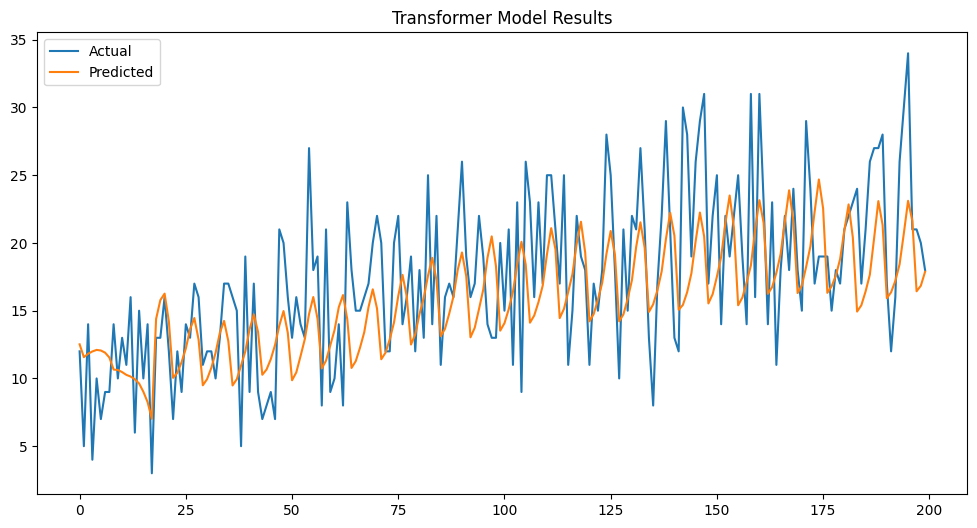

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_val[:200], label="Actual")
plt.plot(tf_pred[:200], label="Predicted")

plt.legend()
plt.title("Transformer Model Results")

plt.savefig("model_comparison(Transformer).png")
plt.show()